In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [3]:
df.shape

(51717, 17)

In [5]:
# dropping columns which are useless for our analysis 
df=df.drop(['url','address','phone','menu_item','dish_liked','reviews_list'],axis=1)

In [9]:
#chnging name of columns 
df = df.rename(columns={
    'approx_cost(for two people)': 'cost',
    'listed_in(type)': 'type',
    'listed_in(city)': 'city'
})
df.shape

(51717, 11)

In [12]:
# fixinf rate column 
import numpy as np 
def rating(value):
    if value =="NEW"or value=="-":
        return np.nan
    else:
        value = str(value).split('/')[0]
        return float(value)

df['rate'] = df['rate'].apply(rating)
df['rate'].head()

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

In [13]:
# fixing commas in cost 
df['cost'] = df['cost'].astype(str).str.replace(',', '').astype(float)
df=df.dropna(subset=['rate','cost'])
df.shape

(41418, 11)

/var/folders/ly/6l78d8rj5q72fr_0knth1jn00000gp/T/ipykernel_6514/173902713.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type',data=df,palette='Set2',order=df['type'].value_counts().index)


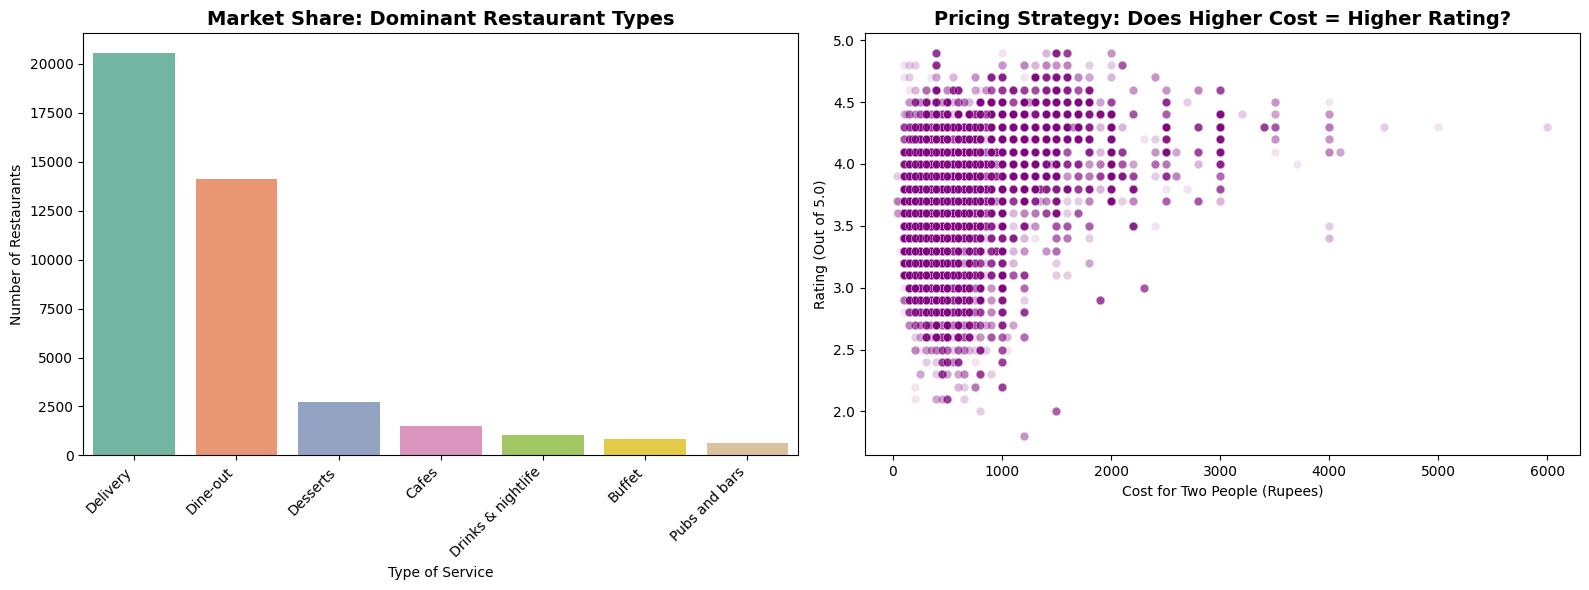

In [14]:
#analysis
#What types of restaurants are dominating the Bangalore market
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.countplot(x='type',data=df,palette='Set2',order=df['type'].value_counts().index)
plt.title('Market Share: Dominant Restaurant Types', fontsize=14, fontweight='bold')
plt.xlabel('Type of Service')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')

#Pricing Strategy
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd chart
sns.scatterplot(x='cost', y='rate', data=df, alpha=0.1, color='purple')
plt.title('Pricing Strategy: Does Higher Cost = Higher Rating?', fontsize=14, fontweight='bold')
plt.xlabel('Cost for Two People (Rupees)')
plt.ylabel('Rating (Out of 5.0)')

plt.tight_layout()
plt.show()

/var/folders/ly/6l78d8rj5q72fr_0knth1jn00000gp/T/ipykernel_6514/1104879349.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')


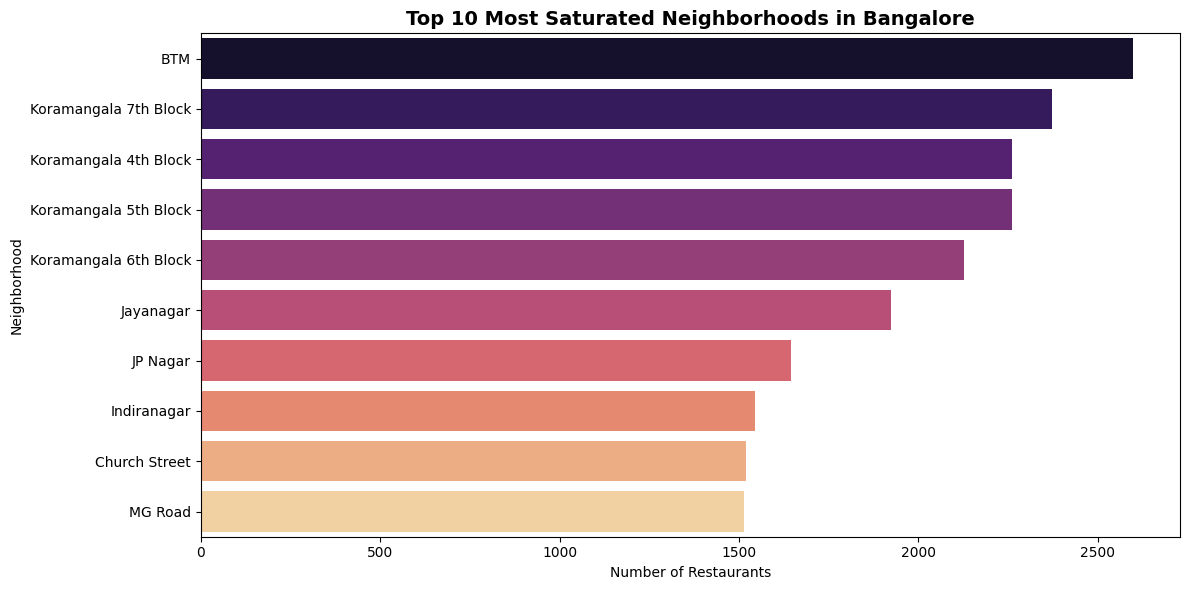

In [16]:
#where to open a new restaurant
# top 10 neighborhoods 
top_locations = df['city'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')

#labels
plt.title('Top 10 Most Saturated Neighborhoods in Bangalore', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Neighborhood')

plt.tight_layout()
plt.show()

In [18]:

#competitor analysis for btm
# Filter the dataset for btm
btm_restaurants = df[df['city'] == 'BTM']

# We also filter for restaurants that cost more than 1000 to find the "Premium" competitors
premium_btm = btm_restaurants[btm_restaurants['cost'] >= 1000]
top_premium_btm = premium_btm.sort_values(by='rate', ascending=False)

top_premium_btm[['name', 'rate', 'cost', 'type']].head(10)

,name,rate,cost,type
8260,AB's - Absolute Barbecues,4.9,1600.0,Buffet
8275,Asia Kitchen By Mainland China,4.9,1500.0,Buffet
11504,Asia Kitchen By Mainland China,4.9,1500.0,Pubs and bars
10389,AB's - Absolute Barbecues,4.9,1600.0,Dine-out
9099,Asia Kitchen By Mainland China,4.9,1500.0,Delivery
10879,Asia Kitchen By Mainland China,4.9,1500.0,Dine-out
11459,House Of Commons,4.8,1000.0,Drinks & nightlife
9935,House Of Commons,4.8,1000.0,Delivery
11505,House Of Commons,4.8,1000.0,Pubs and bars
10886,House Of Commons,4.8,1000.0,Dine-out
